In [ ]:
!pip install kaggle
!pip install nltk

In [ ]:
#Magdi Bakri Mohammed - 20220736
#Amin Tariq Amin Abbas - 20220772
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from PIL import Image
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from google.colab import files
files.upload() # عشان كاجل

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"magdibakri","key":"27e87fadbeb7f4e5ba64014000cd50c3"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d adityajn105/flickr8k


Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
 97% 1.01G/1.04G [00:05<00:00, 157MB/s]
100% 1.04G/1.04G [00:05<00:00, 212MB/s]


In [ ]:
!unzip -q flickr8k.zip
!ls


captions.txt  flickr8k.zip  Images  sample_data


In [ ]:
# ريفيو
df = pd.read_csv('captions.txt')
print("Total captions:", len(df))
df.head()


Total captions: 40455


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [ ]:
captions_dict = {}
for i, row in df.iterrows():
    img = row['image']
    caption = row['caption']
    if img not in captions_dict:
        captions_dict[img] = []
    captions_dict[img].append(caption)

print(f"Loaded {len(captions_dict)} unique image IDs.")

Loaded 8091 unique image IDs.


In [ ]:
def clean_caption(caption):
    caption = caption.lower()
    caption = re.sub(r"[^a-z ]+", "", caption)
    caption = caption.strip()
    return caption

# startseq and endseq
for img_id in captions_dict:
    cleaned = []
    for cap in captions_dict[img_id]:
        cap = clean_caption(cap)
        cap = f"startseq {cap} endseq"
        cleaned.append(cap)
    captions_dict[img_id] = cleaned

# سامبل
for img, caps in list(captions_dict.items())[:2]:
    print(f"{img}:")
    for c in caps:
        print("  ", c)

1000268201_693b08cb0e.jpg:
   startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq
   startseq a girl going into a wooden building endseq
   startseq a little girl climbing into a wooden playhouse endseq
   startseq a little girl climbing the stairs to her playhouse endseq
   startseq a little girl in a pink dress going into a wooden cabin endseq
1001773457_577c3a7d70.jpg:
   startseq a black dog and a spotted dog are fighting endseq
   startseq a black dog and a tricolored dog playing with each other on the road endseq
   startseq a black dog and a white dog with brown spots are staring at each other in the street endseq
   startseq two dogs of different breeds looking at each other on the road endseq
   startseq two dogs on pavement moving toward each other endseq


In [ ]:
all_captions = []
for cap_list in captions_dict.values():
    all_captions.extend(cap_list)

print(f"Total cleaned captions: {len(all_captions)}")


Total cleaned captions: 40455


In [ ]:
# توكينيزر
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

# حجم الفوكابلري
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary Size: {vocab_size}")


Vocabulary Size: 8781


In [ ]:
# اقصى حد
max_length = max(len(cap.split()) for cap in all_captions)
print(f"Max caption length: {max_length}")


Max caption length: 37


In [ ]:
# InceptionV3 without final layer
model_cnn = InceptionV3(weights='imagenet')
model_cnn = Model(inputs=model_cnn.input, outputs=model_cnn.layers[-2].output)

model_cnn.summary()


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:

from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def preprocess_image(img_path):
    img = load_img(img_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img


In [ ]:
import glob

images_dir = "Images/"
features = {}

# نجيب المسار
image_files = glob.glob(images_dir + '*.jpg')

for img_path in tqdm(image_files[:8000]):
    img_id = os.path.basename(img_path)
    img = preprocess_image(img_path)
    feature = model_cnn.predict(img, verbose=0)
    features[img_id] = feature

print(f"Extracted features for {len(features)} images.")


  0%|          | 0/8000 [00:00<?, ?it/s]

Extracted features for 8000 images.


In [ ]:
# image id with caption and feature
image_ids = list(captions_dict.keys())
features = {k: features[k] for k in image_ids if k in features}
print(f"Filtered features: {len(features)}")


Filtered features: 8000


In [ ]:
def data_generator(captions_dict, features, tokenizer, max_length, vocab_size, batch_size):
    while True:
        X1, X2, y = [], [], []
        n = 0

        for img_id, caps in captions_dict.items():
            if img_id not in features:
                continue

            feature = features[img_id][0]  # shape (2048,)
            for cap in caps:
                seq = tokenizer.texts_to_sequences([cap])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

            n += 1
            if n == batch_size:
                yield ((np.array(X1), np.array(X2)), np.array(y))
                X1, X2, y = [], [], []
                n = 0


In [ ]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model

# image feature input (2048-dim)
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# text input
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

# combine image and text
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# final model
model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 37, 256)   │  2,247,936 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 37, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8781)      │  2,256,717 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,620,301 (21.44 MB)

 Trainable params: 5,620,301 (21.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# التريننق
from tensorflow.keras.callbacks import ModelCheckpoint

batch_size = 32
epochs = 25
steps = len(captions_dict) // batch_size

checkpoint = ModelCheckpoint("model_caption.h5", monitor='loss', save_best_only=True)


In [ ]:
train_generator = data_generator(
    captions_dict, features, tokenizer, max_length, vocab_size, batch_size
)


In [ ]:
model.fit(
    train_generator,
    epochs=epochs,
    steps_per_epoch=steps,
    callbacks=[checkpoint],
    verbose=1
)


Epoch 1/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - loss: 5.4559

252/252 ━━━━━━━━━━━━━━━━━━━━ 91s 342ms/step - loss: 5.4528
Epoch 2/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - loss: 3.6741

252/252 ━━━━━━━━━━━━━━━━━━━━ 86s 343ms/step - loss: 3.6737
Epoch 3/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - loss: 3.2847

252/252 ━━━━━━━━━━━━━━━━━━━━ 85s 338ms/step - loss: 3.2844
Epoch 4/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - loss: 3.0657

252/252 ━━━━━━━━━━━━━━━━━━━━ 86s 341ms/step - loss: 3.0655
Epoch 5/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - loss: 2.9097

...

252/252 ━━━━━━━━━━━━━━━━━━━━ 85s 337ms/step - loss: 2.0808
Epoch 22/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - loss: 2.0598

252/252 ━━━━━━━━━━━━━━━━━━━━ 85s 338ms/step - loss: 2.0598
Epoch 23/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - loss: 2.0363

252/252 ━━━━━━━━━━━━━━━━━━━━ 84s 335ms/step - loss: 2.0363
Epoch 24/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - loss: 2.0209

252/252 ━━━━━━━━━━━━━━━━━━━━ 85s 337ms/step - loss: 2.0209
Epoch 25/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - loss: 2.0115

252/252 ━━━━━━━━━━━━━━━━━━━━ 85s 338ms/step - loss: 2.0115


In [ ]:
# genearting the caption
def generate_caption(model, tokenizer, photo_feature, max_length):
    in_text = 'startseq'

    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        y_pred = model.predict([photo_feature, sequence], verbose=0)
        y_pred = np.argmax(y_pred)

        word = tokenizer.index_word.get(y_pred)
        if word is None:
            break

        in_text += ' ' + word
        if word == 'endseq':
            break

    final_caption = in_text.replace('startseq', '').replace('endseq', '').strip()
    return final_caption


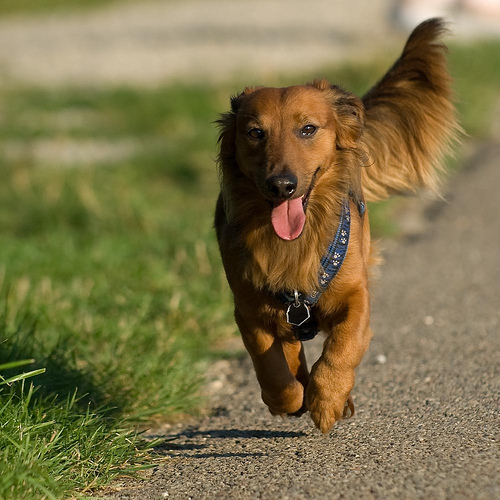

Caption: a dog runs through the grass


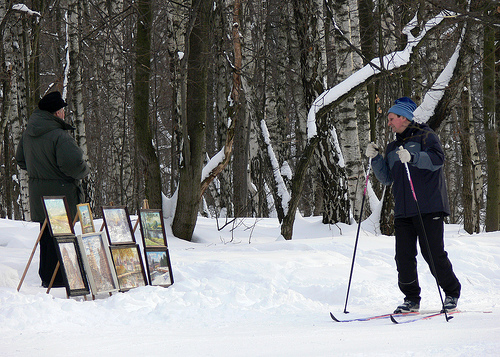

Caption: a man skis down a snowy hill


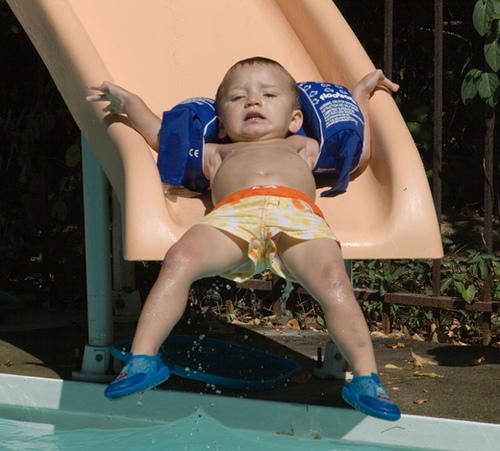

Caption: a boy in a bathing suit jumps into a pool


In [ ]:
from IPython.display import Image as IPImage, display

# load images
image_paths = [
    "Images/1089181217_ee1167f7af.jpg",
    "Images/101669240_b2d3e7f17b.jpg",
    "Images/1303335399_b3facd47ab.jpg",
]

# كل الصور
for img_path in image_paths:
    img = preprocess_image(img_path)
    feature = model_cnn.predict(img, verbose=0)
    caption = generate_caption(model, tokenizer, feature, max_length)

    display(IPImage(img_path))
    print("Caption:", caption)
    print("="*80)
